# Inspect All-Unsolved Tasks

This notebook inspects the tasks that remained unsolved across all experiments. It computes raw grid features, summarizes residual failure patterns, generates the all-unsolved profile figure, and creates visual inspection sheets for qualitative analysis.


## 1. Setup

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display


def resolve_project_root() -> Path:
    """Walk upward from cwd until we find a directory that contains final_outputs/."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "final_outputs").is_dir():
            return candidate
        legacy = candidate / "sample" / "final_outputs"
        if legacy.is_dir():
            return candidate / "sample"
    raise FileNotFoundError(
        "Could not locate experiment outputs. Expected a `final_outputs` directory "
        "(at the project root or under `sample/`). Unzip `final_outputs.zip` if needed, "
        "and run the notebook with the working directory inside the repo (e.g. open "
        "the project folder in Cursor/Jupyter)."
    )


ROOT = resolve_project_root()
print(f"Project root: {ROOT}")


Project root: /Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation


## 2. Helper functions

This section defines the data-loading, metric-computation, CSV-writing, and plotting functions used in the analysis below.


In [4]:
from __future__ import annotations

import ast
import csv
from collections import Counter, deque
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


# ROOT is defined in the setup cell.
ANALYSIS_DIR = ROOT / "analysis_outputs"
UNSOLVED_PATH = ANALYSIS_DIR / "all_experiments_unsolved_tasks.csv"
DIFFICULTY_SUMMARY_PATH = ANALYSIS_DIR / "difficulty_accuracy_summary.csv"
RESULTS_PATH = ROOT / "final_outputs" / "4_good_hypo_program" / "results.csv"
FEATURES_PATH = ANALYSIS_DIR / "all_unsolved_task_raw_features.csv"
PROFILE_PATH = ANALYSIS_DIR / "all_unsolved_task_profile.png"

ARC_PALETTE = {
    0: (18, 18, 18),
    1: (0, 116, 217),
    2: (220, 50, 47),
    3: (46, 204, 64),
    4: (255, 220, 0),
    5: (128, 128, 128),
    6: (240, 18, 190),
    7: (255, 133, 27),
    8: (127, 219, 255),
    9: (135, 12, 37),
}


def parse_grid(value: str) -> list[list[int]] | None:
    if not value or not value.strip().startswith("["):
        return None
    return ast.literal_eval(value)


def dims(grid: list[list[int]]) -> tuple[int, int]:
    return len(grid), len(grid[0]) if grid else 0


def flat(grid: list[list[int]]) -> list[int]:
    return [value for row in grid for value in row]


def nonzero_count(grid: list[list[int]]) -> int:
    return sum(1 for value in flat(grid) if value != 0)


def colors(grid: list[list[int]], include_black: bool = True) -> list[int]:
    values = set(flat(grid))
    if not include_black:
        values.discard(0)
    return sorted(values)


def component_count(grid: list[list[int]]) -> int:
    height, width = dims(grid)
    seen: set[tuple[int, int]] = set()
    count = 0

    for row in range(height):
        for col in range(width):
            color = grid[row][col]
            if color == 0 or (row, col) in seen:
                continue
            count += 1
            queue: deque[tuple[int, int]] = deque([(row, col)])
            seen.add((row, col))

            while queue:
                cur_row, cur_col = queue.popleft()
                for row_delta, col_delta in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    next_row = cur_row + row_delta
                    next_col = cur_col + col_delta
                    if not (0 <= next_row < height and 0 <= next_col < width):
                        continue
                    if (next_row, next_col) in seen:
                        continue
                    if grid[next_row][next_col] != color:
                        continue
                    seen.add((next_row, next_col))
                    queue.append((next_row, next_col))

    return count


def changed_cells(input_grid: list[list[int]], output_grid: list[list[int]]) -> int | str:
    if dims(input_grid) != dims(output_grid):
        return ""
    return sum(
        1
        for row in range(len(input_grid))
        for col in range(len(input_grid[0]))
        if input_grid[row][col] != output_grid[row][col]
    )


def classify_transform(input_grid: list[list[int]], output_grid: list[list[int]]) -> str:
    input_height, input_width = dims(input_grid)
    output_height, output_width = dims(output_grid)
    input_area = input_height * input_width
    output_area = output_height * output_width

    if (input_height, input_width) == (output_height, output_width):
        return "same-size edit/reconstruction"
    if output_area < input_area:
        return "crop/extract/compress"
    if output_area > input_area:
        return "expand/generate canvas"
    return "reshape same area"


def read_first_result_rows() -> dict[str, dict[str, str]]:
    rows: dict[str, dict[str, str]] = {}
    with RESULTS_PATH.open("r", encoding="utf-8", newline="") as file:
        for row in csv.DictReader(file):
            rows.setdefault(row["task_id"], row)
    return rows


def write_raw_features() -> list[dict[str, Any]]:
    unsolved_rows = list(csv.DictReader(UNSOLVED_PATH.open("r", encoding="utf-8")))
    result_rows = read_first_result_rows()
    output_rows: list[dict[str, Any]] = []

    for row in unsolved_rows:
        task_id = row["task_id"]
        result = result_rows[task_id]
        input_grid = parse_grid(result["input_grid"])
        output_grid = parse_grid(result["output_grid"])
        pred_grid = parse_grid(result.get("pred_output_grid", ""))
        if input_grid is None or output_grid is None:
            continue

        input_height, input_width = dims(input_grid)
        output_height, output_width = dims(output_grid)
        input_area = input_height * input_width
        output_area = output_height * output_width
        input_nonzero_colors = colors(input_grid, include_black=False)
        output_nonzero_colors = colors(output_grid, include_black=False)
        train_pair_count = len(
            list((ROOT / "train_examples" / task_id).glob(f"{task_id}_train_input_*.png"))
        )

        feature_row: dict[str, Any] = {
            "task_id": task_id,
            "difficulty": row["difficulty"],
            "train_pairs": train_pair_count,
            "input_shape": f"{input_height}x{input_width}",
            "output_shape": f"{output_height}x{output_width}",
            "transform_kind": classify_transform(input_grid, output_grid),
            "input_area": input_area,
            "output_area": output_area,
            "area_ratio_out_in": round(output_area / input_area, 3),
            "input_nonzero_density": round(nonzero_count(input_grid) / input_area, 3),
            "output_nonzero_density": round(nonzero_count(output_grid) / output_area, 3),
            "input_colors": "".join(map(str, colors(input_grid))),
            "output_colors": "".join(map(str, colors(output_grid))),
            "input_nonzero_color_count": len(input_nonzero_colors),
            "output_nonzero_color_count": len(output_nonzero_colors),
            "output_colors_subset_input": set(output_nonzero_colors).issubset(
                set(input_nonzero_colors)
            ),
            "input_components": component_count(input_grid),
            "output_components": component_count(output_grid),
            "same_shape_changed_cells": changed_cells(input_grid, output_grid),
            "good_hypothesis_words": len((result.get("best_hypothesis") or "").split()),
            "good_hypothesis": result.get("best_hypothesis") or "",
        }
        if pred_grid is not None:
            pred_height, pred_width = dims(pred_grid)
            feature_row["pred_shape"] = f"{pred_height}x{pred_width}"
            feature_row["pred_matches_shape"] = dims(pred_grid) == dims(output_grid)
            feature_row["pred_nonzero_density"] = round(
                nonzero_count(pred_grid) / (pred_height * pred_width), 3
            )

        output_rows.append(feature_row)

    FEATURES_PATH.parent.mkdir(parents=True, exist_ok=True)
    with FEATURES_PATH.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=list(output_rows[0]))
        writer.writeheader()
        writer.writerows(output_rows)

    return output_rows


def load_font(size: int) -> ImageFont.ImageFont:
    try:
        return ImageFont.truetype("arial.ttf", size)
    except OSError:
        return ImageFont.load_default()


def render_grid(grid: list[list[int]], max_size: int = 132) -> Image.Image:
    height, width = dims(grid)
    cell = max(3, min(max_size // max(height, 1), max_size // max(width, 1)))
    image = Image.new("RGB", (width * cell, height * cell), (245, 245, 245))
    draw = ImageDraw.Draw(image)

    for row_index, row in enumerate(grid):
        for col_index, value in enumerate(row):
            draw.rectangle(
                [
                    col_index * cell,
                    row_index * cell,
                    (col_index + 1) * cell - 1,
                    (row_index + 1) * cell - 1,
                ],
                fill=ARC_PALETTE.get(value, (255, 255, 255)),
            )

    if cell >= 8:
        for col in range(width + 1):
            draw.line([(col * cell, 0), (col * cell, height * cell)], fill=(60, 60, 60))
        for row in range(height + 1):
            draw.line([(0, row * cell), (width * cell, row * cell)], fill=(60, 60, 60))

    return image


def thumbnail_from_file(path: Path, size: int = 132) -> Image.Image:
    image = Image.open(path).convert("RGB")
    image.thumbnail((size, size), Image.Resampling.LANCZOS)
    background = Image.new("RGB", (size, size), (246, 246, 244))
    background.paste(image, ((size - image.width) // 2, (size - image.height) // 2))
    return background


def write_inspection_sheets() -> list[Path]:
    unsolved_rows = list(csv.DictReader(UNSOLVED_PATH.open("r", encoding="utf-8")))
    result_rows = read_first_result_rows()
    font = load_font(18)
    tiny_font = load_font(11)
    blocks: list[Image.Image] = []

    for row in unsolved_rows:
        task_id = row["task_id"]
        result = result_rows[task_id]
        train_dir = ROOT / "train_examples" / task_id
        pairs: list[tuple[Path, Path, str]] = []
        for input_path in sorted(train_dir.glob(f"{task_id}_train_input_*.png")):
            index = input_path.stem.split("_")[-1]
            output_path = train_dir / f"{task_id}_train_output_{index}.png"
            if output_path.exists():
                pairs.append((input_path, output_path, index))

        block_width = 1260
        label_height = 28
        item_height = 168
        padding = 10
        block = Image.new(
            "RGB", (block_width, label_height + item_height * 2 + padding * 3), "white"
        )
        draw = ImageDraw.Draw(block)
        draw.text(
            (padding, 5),
            f"{task_id}  |  {row['difficulty']}  |  train pairs: {len(pairs)}",
            fill=(35, 35, 35),
            font=font,
        )

        x_pos = padding
        y_pos = label_height + padding
        for input_path, output_path, index in pairs:
            for label, path in ((f"Train In {index}", input_path), (f"Train Out {index}", output_path)):
                draw.text((x_pos, y_pos), label, fill=(80, 80, 80), font=tiny_font)
                block.paste(thumbnail_from_file(path), (x_pos, y_pos + 16))
                x_pos += 140

        x_pos = padding
        y_pos = label_height + padding + item_height
        for label, grid in (
            ("Test Input", parse_grid(result["input_grid"])),
            ("Expected", parse_grid(result["output_grid"])),
            ("4_good Pred", parse_grid(result.get("pred_output_grid", ""))),
        ):
            draw.text((x_pos, y_pos), label, fill=(80, 80, 80), font=tiny_font)
            if grid is not None:
                rendered = render_grid(grid)
                background = Image.new("RGB", (132, 132), (246, 246, 244))
                background.paste(
                    rendered,
                    ((132 - rendered.width) // 2, (132 - rendered.height) // 2),
                )
                block.paste(background, (x_pos, y_pos + 16))
            x_pos += 150

        blocks.append(block)

    output_paths: list[Path] = []
    for index in range(0, len(blocks), 4):
        chunk = blocks[index : index + 4]
        width = max(block.width for block in chunk)
        height = sum(block.height for block in chunk) + 14 * (len(chunk) - 1)
        sheet = Image.new("RGB", (width, height), (238, 238, 236))
        y_pos = 0
        for block in chunk:
            sheet.paste(block, (0, y_pos))
            y_pos += block.height + 14

        output_path = ANALYSIS_DIR / f"all_unsolved_task_inspection_sheet_{index // 4 + 1}.png"
        sheet.save(output_path)
        output_paths.append(output_path)

    return output_paths


def write_profile_figure(feature_rows: list[dict[str, Any]]) -> Path:
    difficulty_order = ["Easy", "Medium", "Hard", "Expert"]
    difficulty_counts = Counter(row["difficulty"] for row in feature_rows)

    difficulty_totals: dict[str, int] = {}
    with DIFFICULTY_SUMMARY_PATH.open("r", encoding="utf-8-sig", newline="") as file:
        for row in csv.DictReader(file):
            if row["experiment_folder"] == "0_output_grid":
                difficulty_totals[row["difficulty"]] = int(row["task_count"])

    difficulty_rates = [
        difficulty_counts[difficulty] / difficulty_totals[difficulty] * 100
        for difficulty in difficulty_order
    ]

    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    bars = ax.bar(
        difficulty_order,
        difficulty_rates,
        color=["#4C78A8", "#F58518", "#E45756", "#72B7B2"],
    )
    ax.set_title("All-Unsolved Rate by Difficulty")
    ax.set_ylabel("Tasks unsolved by all experiments (%)")
    ax.set_ylim(0, max(difficulty_rates) + 8)
    for bar, difficulty, rate in zip(bars, difficulty_order, difficulty_rates):
        label = f"{rate:.1f}%\n({difficulty_counts[difficulty]}/{difficulty_totals[difficulty]})"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.7,
            label,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle("Profile of Tasks Unsolved by All Five Experiments", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    PROFILE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(PROFILE_PATH, dpi=200)
    plt.close(fig)
    return PROFILE_PATH


def main() -> None:
    feature_rows = write_raw_features()
    sheet_paths = write_inspection_sheets()
    profile_path = write_profile_figure(feature_rows)
    print(f"Wrote {len(feature_rows)} raw feature rows to {FEATURES_PATH}")
    print(f"Wrote {len(sheet_paths)} inspection sheets")
    print(f"Wrote profile figure to {profile_path}")


## 3. Load all-unsolved task list

In [5]:
unsolved_df = pd.read_csv(UNSOLVED_PATH)
results_df = pd.read_csv(RESULTS_PATH)
print(f"All-unsolved tasks: {len(unsolved_df)}")
print(f"High-quality hypothesis result rows: {len(results_df)}")
display(unsolved_df.head())

All-unsolved tasks: 16
High-quality hypothesis result rows: 105


,task_id,difficulty,0_output_grid_correct_examples,0_output_grid_test_examples,0_output_grid_example_accuracy,1_program_only_correct_examples,1_program_only_test_examples,1_program_only_example_accuracy,2_hypo_program_correct_examples,2_hypo_program_test_examples,2_hypo_program_example_accuracy,3_hint_hypo_program_correct_examples,3_hint_hypo_program_test_examples,3_hint_hypo_program_example_accuracy,4_good_hypo_program_correct_examples,4_good_hypo_program_test_examples,4_good_hypo_program_example_accuracy
0,150deff5,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
1,28e73c20,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
2,39e1d7f9,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
3,60b61512,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0
4,776ffc46,Easy,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0


## 4. Compute and save raw grid features

In [6]:
feature_rows = write_raw_features()
features_df = pd.DataFrame(feature_rows)
print(FEATURES_PATH)
display(features_df[["task_id", "difficulty", "train_pairs", "input_shape", "output_shape", "transform_kind", "input_components", "output_components", "same_shape_changed_cells", "good_hypothesis_words"]])

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_raw_features.csv


,task_id,difficulty,train_pairs,input_shape,output_shape,transform_kind,input_components,output_components,same_shape_changed_cells,good_hypothesis_words
0,150deff5,Easy,0,8x11,8x11,same-size edit/reconstruction,1,6,24,91
1,28e73c20,Easy,0,18x18,18x18,same-size edit/reconstruction,0,1,180,120
2,39e1d7f9,Easy,0,29x29,29x29,same-size edit/reconstruction,13,34,84,111
3,60b61512,Easy,0,9x9,9x9,same-size edit/reconstruction,3,8,9,85
4,776ffc46,Easy,0,20x20,20x20,same-size edit/reconstruction,11,11,10,99
5,d07ae81c,Easy,0,17x19,17x19,same-size edit/reconstruction,10,64,39,111
6,e6721834,Easy,0,24x12,12x12,crop/extract/compress,16,8,,141
7,e73095fd,Easy,0,16x18,16x18,same-size edit/reconstruction,1,5,15,100
8,ec883f72,Easy,0,12x12,12x12,same-size edit/reconstruction,2,8,6,116
9,4be741c5,Medium,0,14x14,1x4,crop/extract/compress,4,4,,100


## 5. Summarize residual failure patterns

In [7]:
display(pd.crosstab(features_df["difficulty"], features_df["transform_kind"], margins=True))
display(features_df.groupby("transform_kind").agg(tasks=("task_id", "count"), mean_input_area=("input_area", "mean"), mean_output_area=("output_area", "mean"), mean_input_components=("input_components", "mean"), mean_output_components=("output_components", "mean"), mean_hypothesis_words=("good_hypothesis_words", "mean")).round(2))

transform_kind,crop/extract/compress,expand/generate canvas,same-size edit/reconstruction,All
difficulty,,,,
Easy,1,0,8,9
Expert,0,0,1,1
Hard,0,1,1,2
Medium,3,0,1,4
All,4,1,11,16


,tasks,mean_input_area,mean_output_area,mean_input_components,mean_output_components,mean_hypothesis_words
transform_kind,,,,,,
crop/extract/compress,4,252.25,91.00,13.75,6.00,121.75
expand/generate canvas,1,32.00,256.00,6.00,5.00,102.00
same-size edit/reconstruction,11,290.18,290.18,8.27,19.09,107.27


## 7. Generate and display percentage-based profile figure

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_profile.png


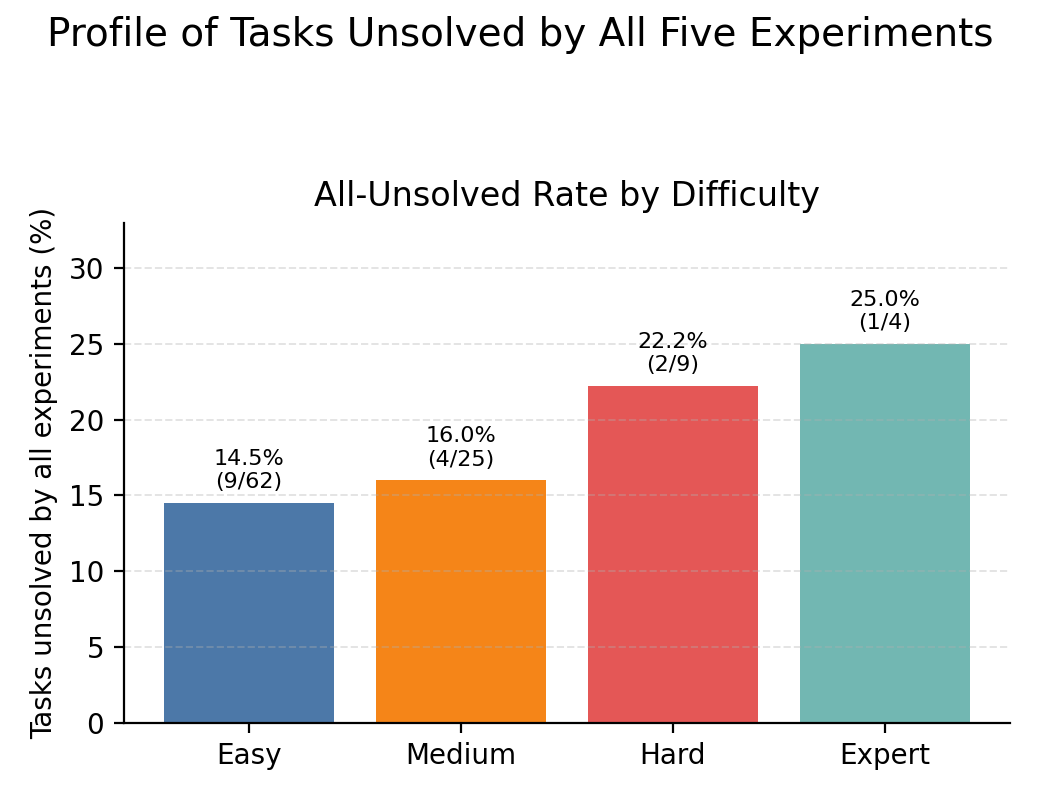

In [8]:
profile_path = write_profile_figure(feature_rows)
print(profile_path)
display(DisplayImage(filename=str(profile_path)))

## 7. Generate and display visual inspection sheets

These sheets show train inputs, train outputs, test input, expected output, and the high-quality hypothesis prediction for each all-unsolved task.

Inspection sheets: 4
/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_inspection_sheet_1.png


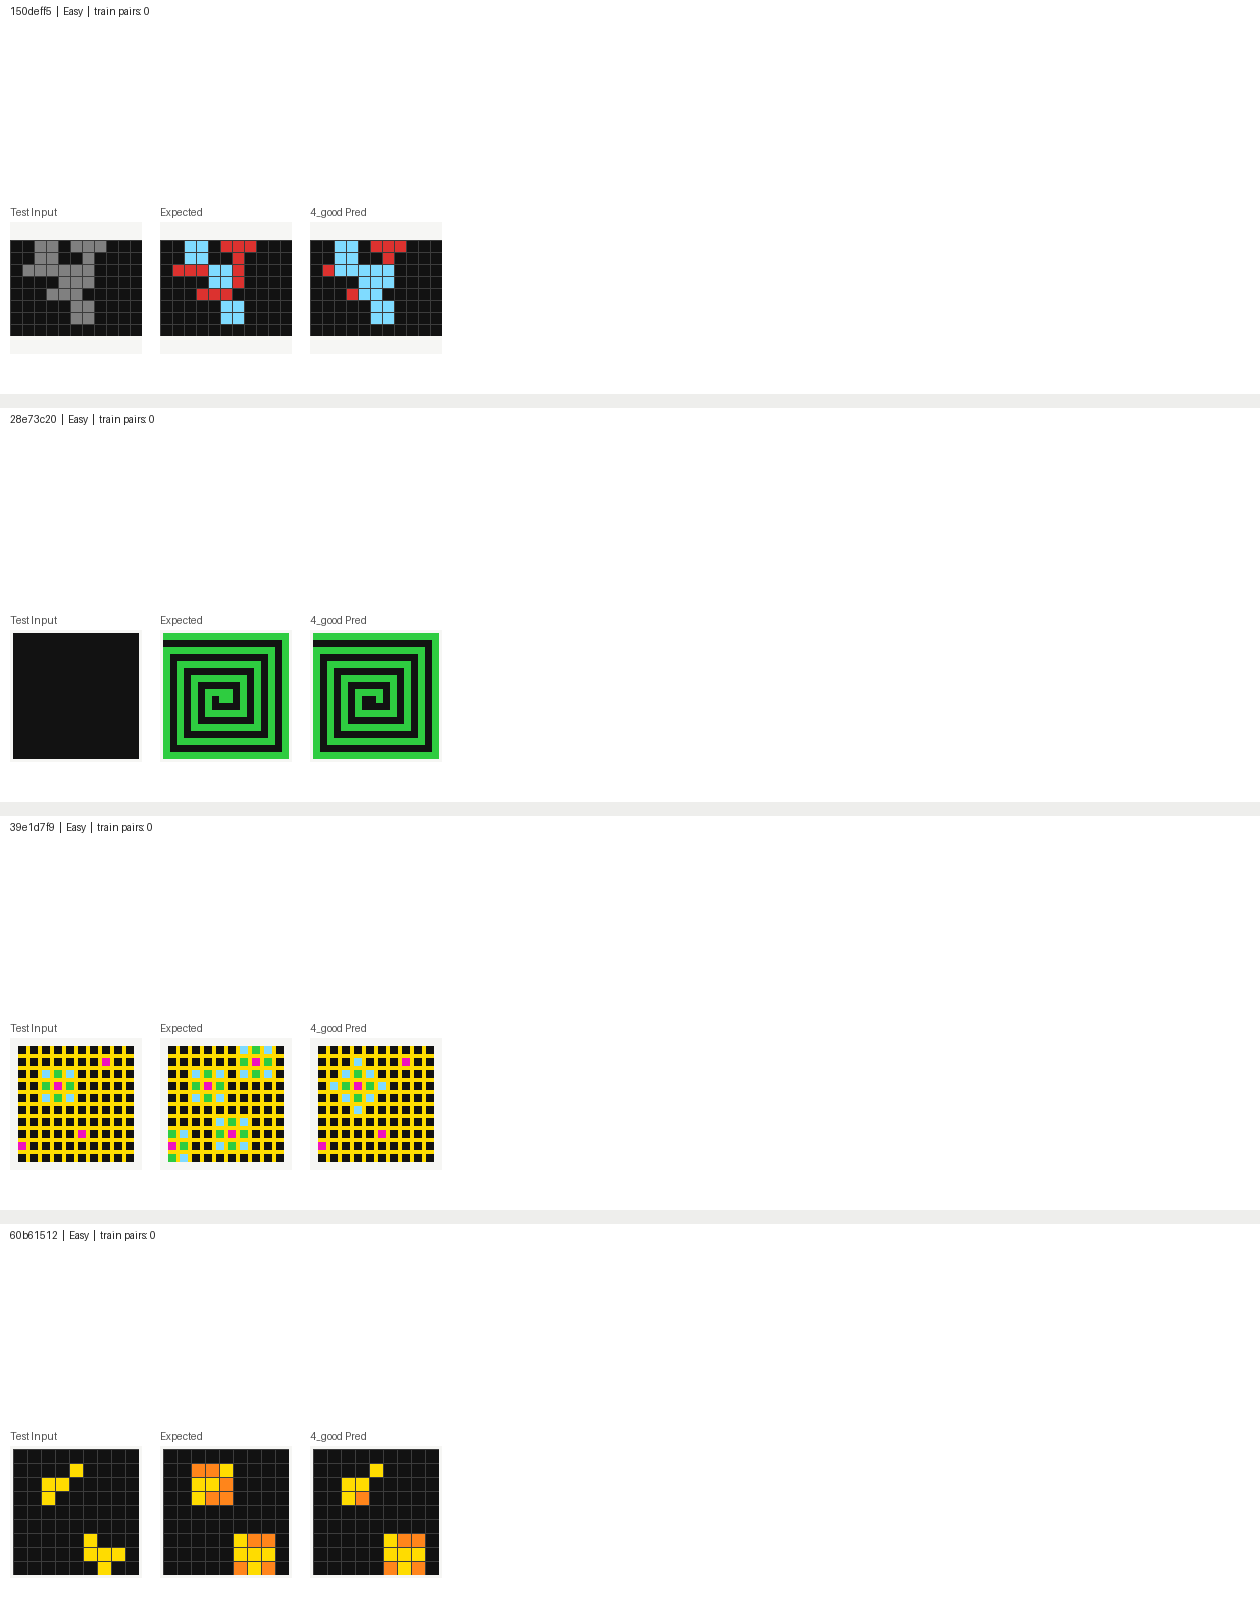

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_inspection_sheet_2.png


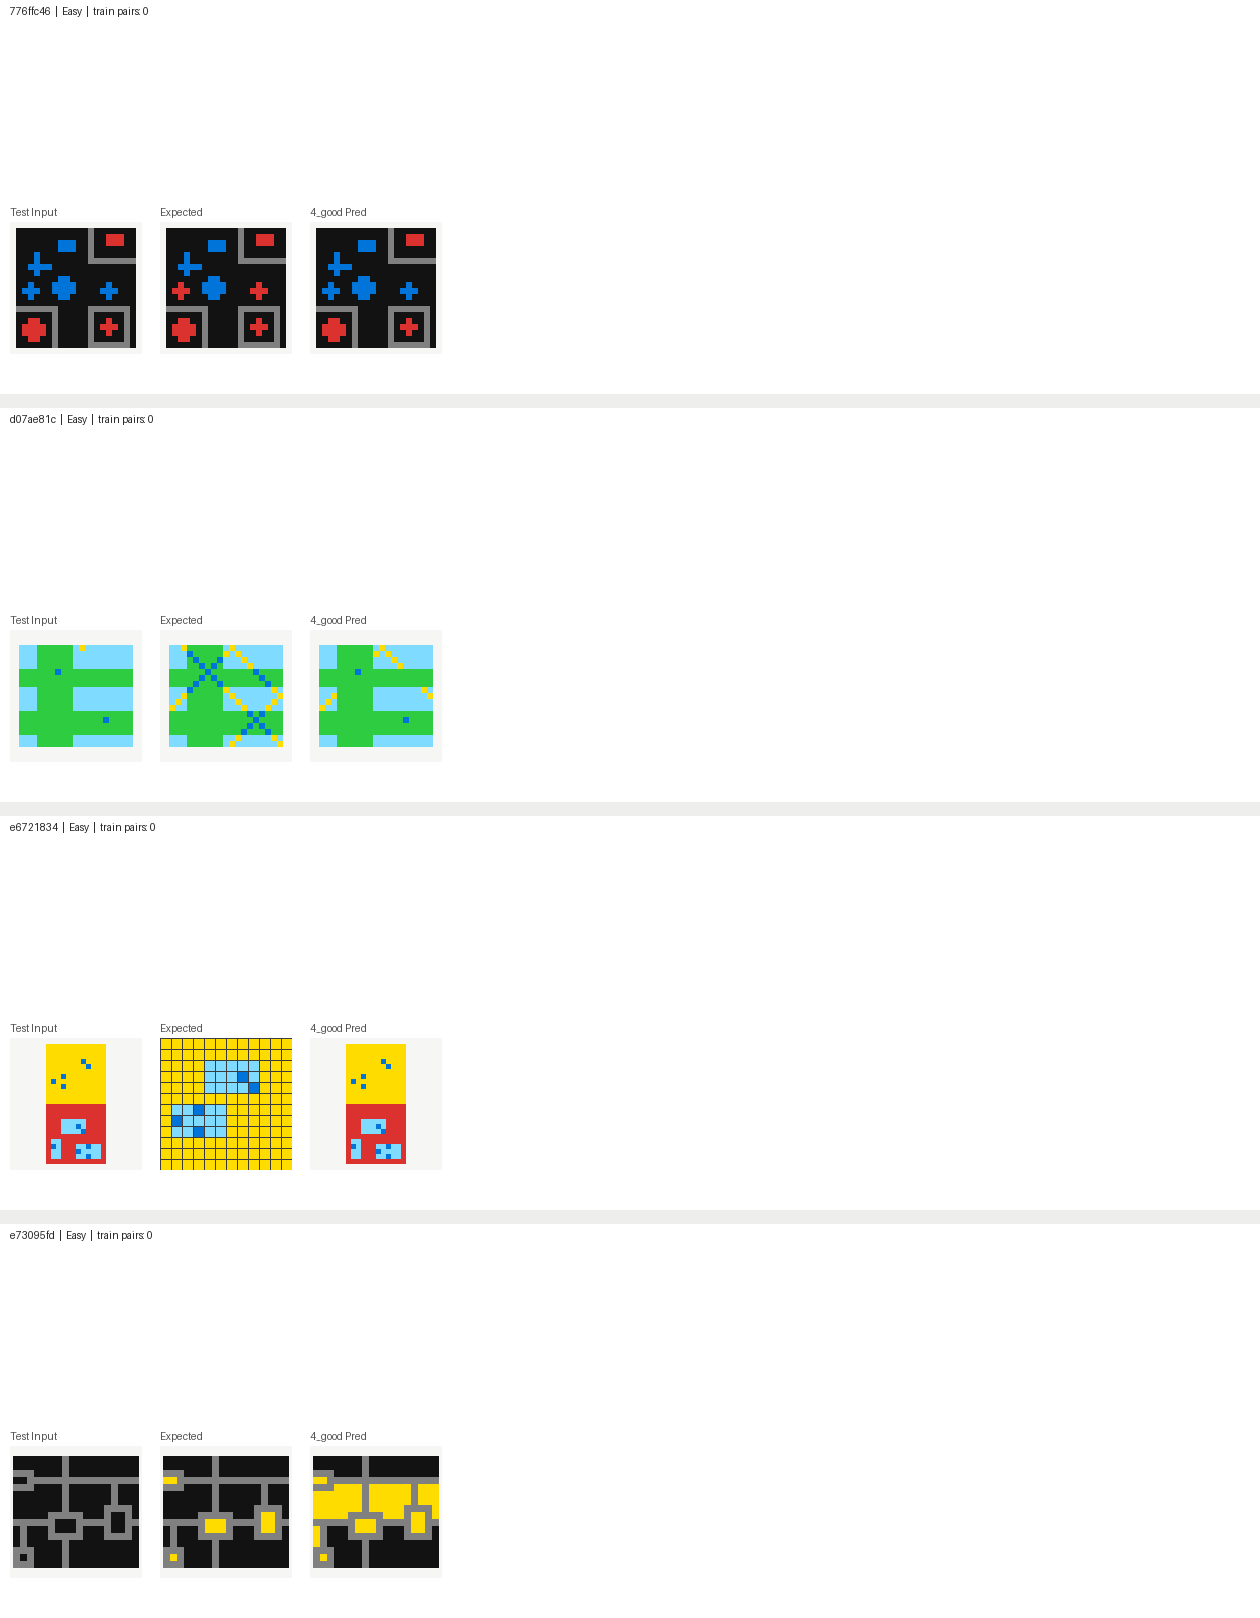

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_inspection_sheet_3.png


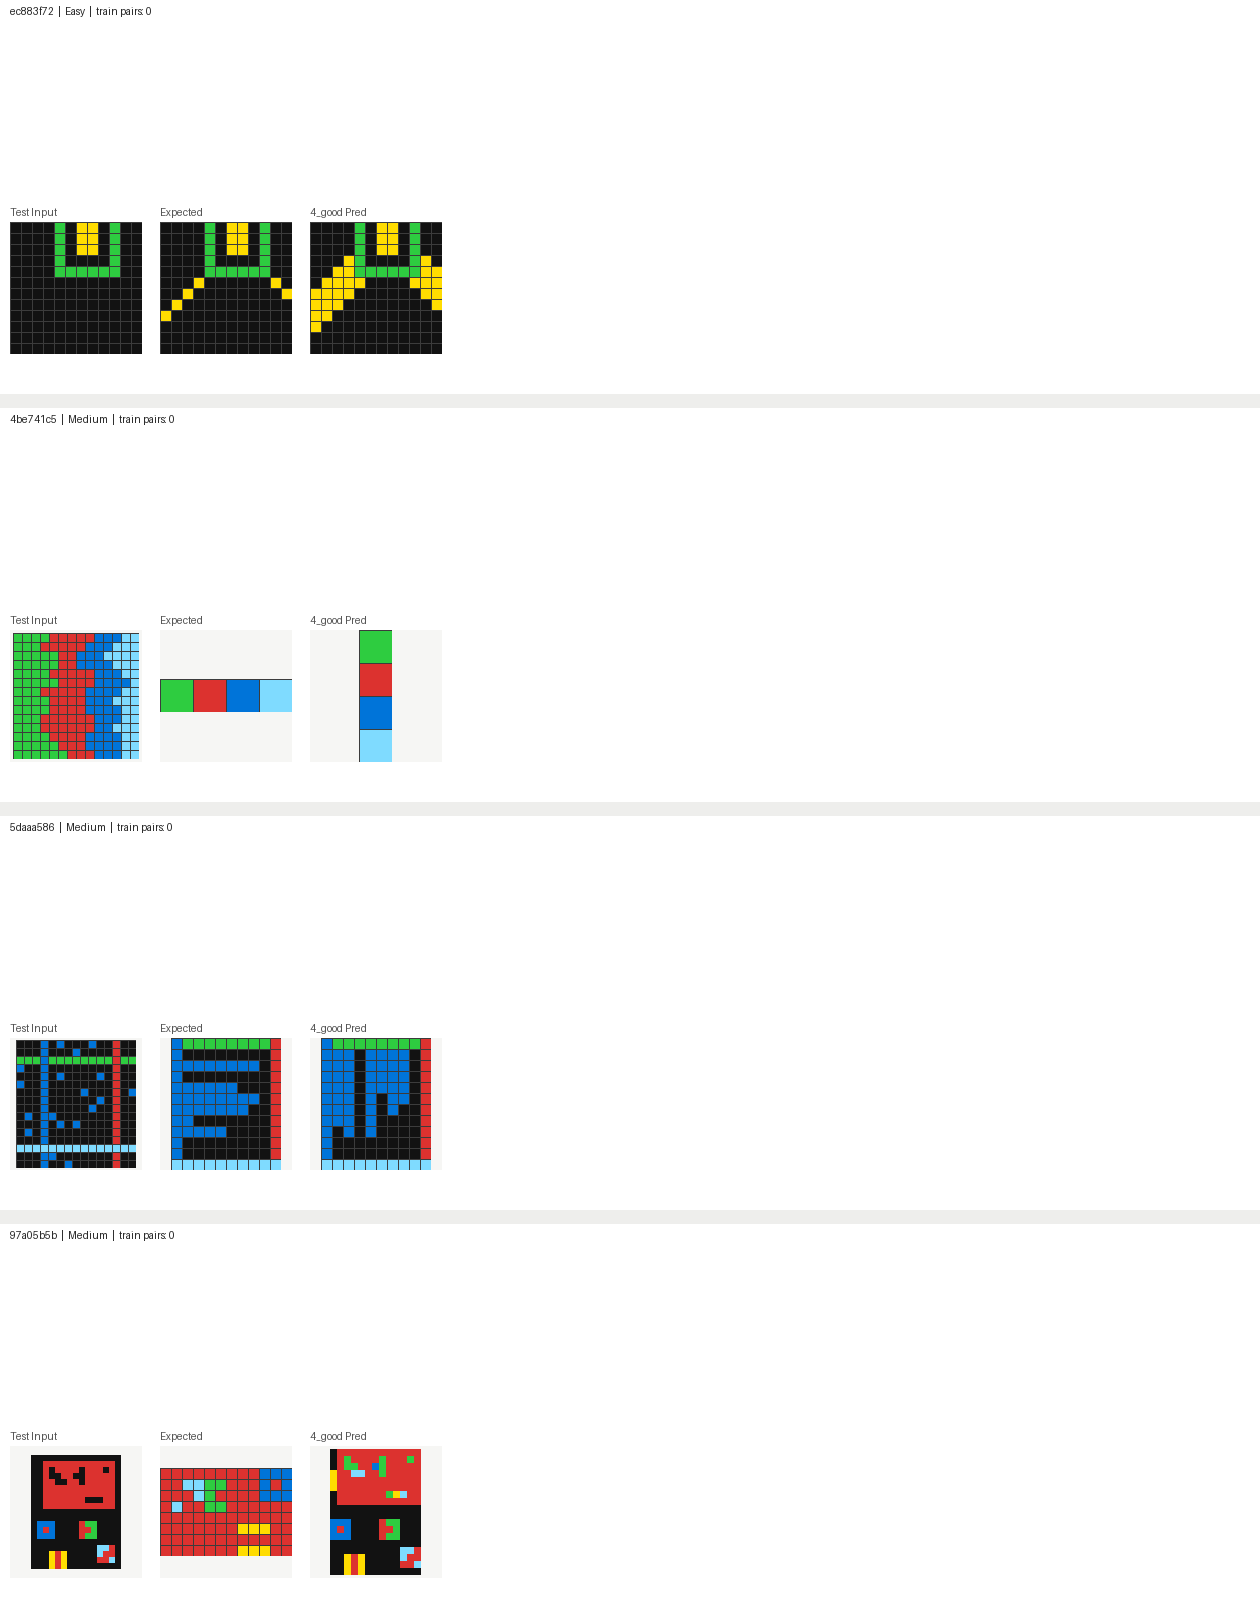

/Users/liubeisong/Desktop/2026_Spring/CCM/FT-Hypothesis-Generation/analysis_outputs/all_unsolved_task_inspection_sheet_4.png


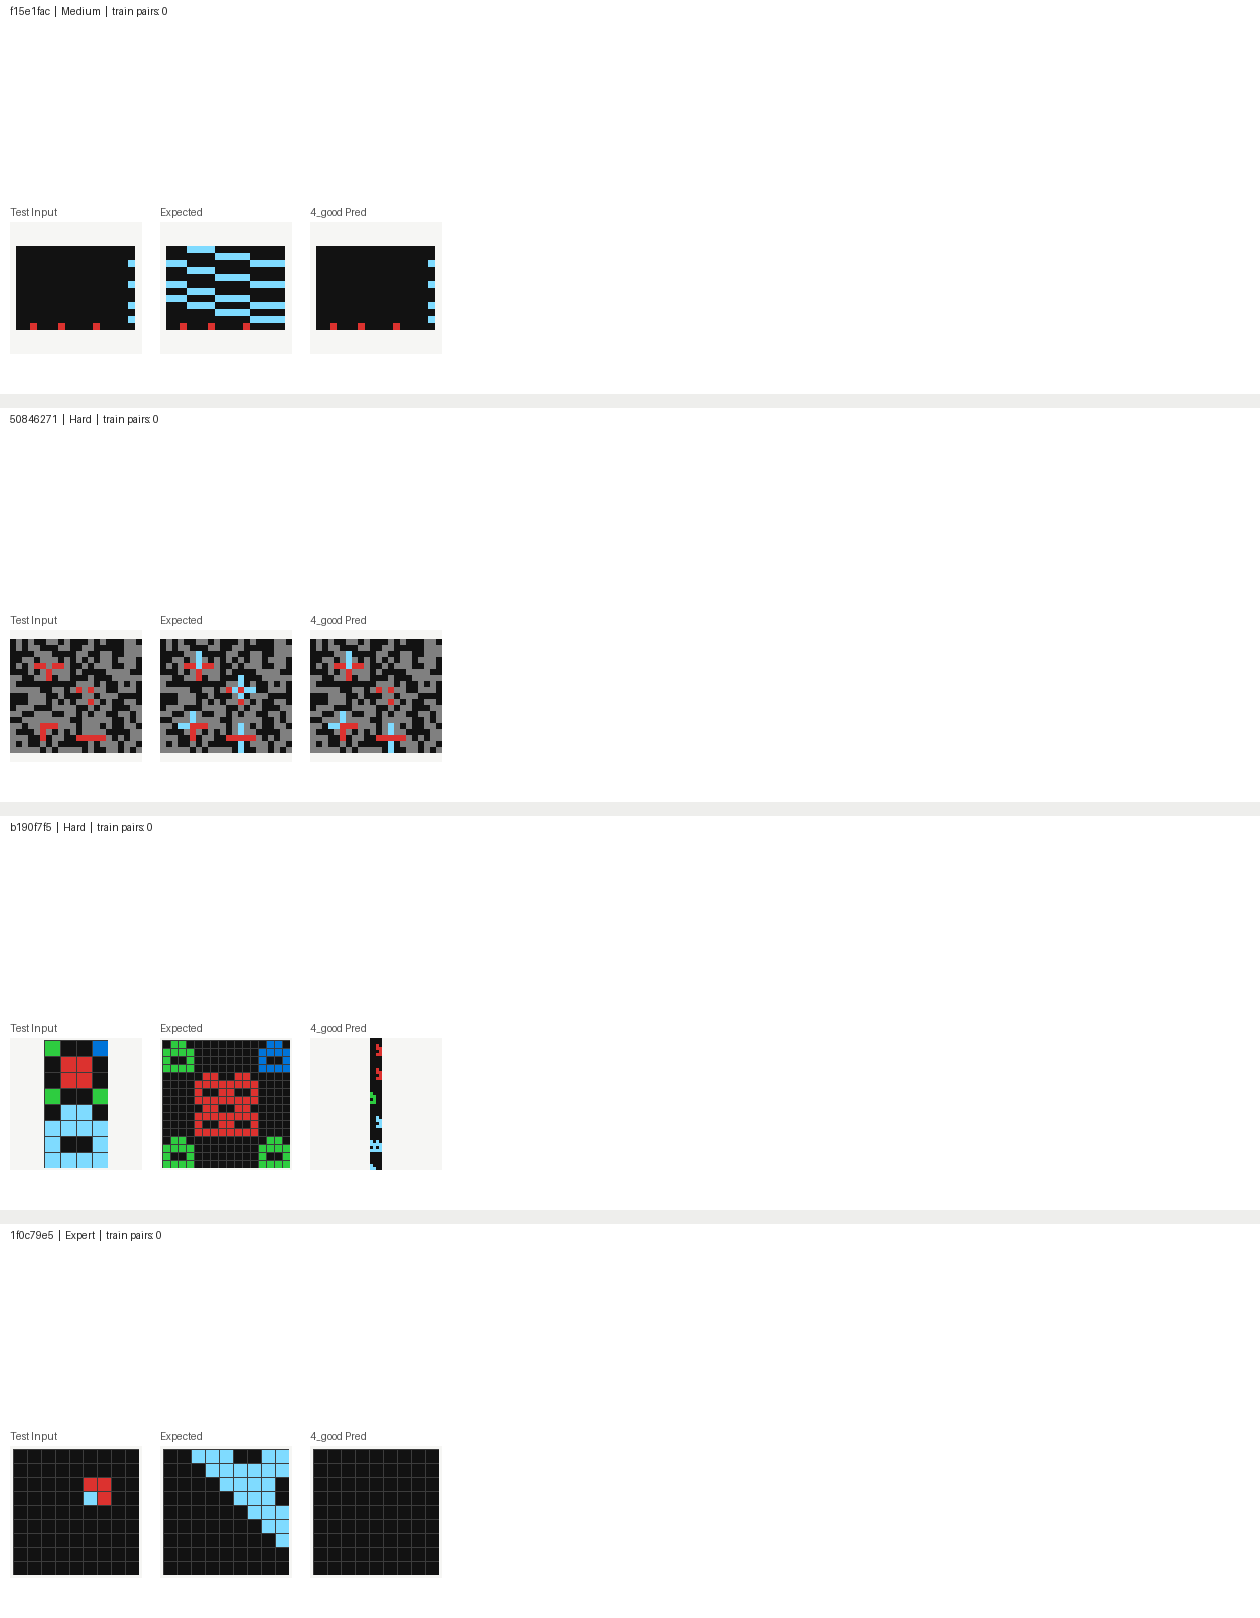

In [9]:
sheet_paths = write_inspection_sheets()
print(f"Inspection sheets: {len(sheet_paths)}")
for path in sheet_paths:
    print(path)
    display(DisplayImage(filename=str(path)))